# EDA & Feature Engineering — Complete ML Engineer Interview Reference

A single, self-contained, **runnable** Jupyter notebook covering Exploratory Data
Analysis and Feature Engineering end-to-end, built around the real **Titanic**
dataset. Every section includes: theory, intuition, runnable code, real output,
best practices, common mistakes, and interview Q&A.

**How to use this notebook:** Run all cells top to bottom (`Kernel > Restart & Run All`).
Every code cell is executable and produces real output on the Titanic dataset.

**Sections**
1. Introduction  2. Loading Data  3. Basic Dataset Info  4. Data Quality Assessment
5. Data Cleaning  6. Missing Value Treatment  7. Outlier Detection  8. Univariate Analysis
9. Bivariate Analysis  10. Multivariate Analysis  11. Feature Engineering Overview
12. Encoding  13. Scaling  14. Handling Skewness  15. Feature Creation  16. Feature Selection
17. Dimensionality Reduction  18. Handling Imbalanced Data  19. Pipelines
20. Complete Titanic Project (end-to-end)

In [1]:
# Global imports used throughout the notebook
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

print("Environment ready:", pd.__version__, np.__version__)

Environment ready: 3.0.2 2.4.4


## 1. Introduction

### What is EDA?
Exploratory Data Analysis (EDA) is the process of investigating a dataset to
summarize its main characteristics, often using visual and statistical methods,
**before** modeling. It answers: *what does the data look like, what's wrong
with it, and what signals does it contain?*

### Why EDA?
- Models are only as good as the data fed into them ("garbage in, garbage out").
- Reveals data quality issues (missing values, duplicates, outliers, wrong types).
- Reveals relationships/patterns that guide feature engineering and model choice.
- Prevents silent bugs (e.g., leakage, mis-encoded categories) from reaching production.

### Data Science Workflow (typical)
`Business Problem → Data Collection → EDA → Cleaning → Feature Engineering → Modeling → Evaluation → Deployment → Monitoring`

### CRISP-DM Process
1. **Business Understanding** – define the problem and success metric.
2. **Data Understanding** – collect and explore data (this is EDA).
3. **Data Preparation** – clean, transform, engineer features.
4. **Modeling** – select and train algorithms.
5. **Evaluation** – validate against business goals.
6. **Deployment** – ship to production and monitor.

### Types of Data
- **Numerical**: Continuous (height, fare) vs Discrete (number of siblings).
- **Categorical**: Nominal (no order — e.g., Embarked) vs Ordinal (has order — e.g., Pclass).
- **Structured** (tables/rows-columns) vs **Unstructured** (text, images, audio).
- **Time-series**: data indexed by time.

### Features vs Target
- **Features (X)**: input variables used to make predictions.
- **Target (y)**: the variable being predicted (e.g., `Survived` in Titanic).

**Interview Questions**
- *Q: Why is EDA considered the most time-consuming part of an ML project?*
  A: In practice 60–80% of project time goes to understanding and cleaning data,
  because raw data is almost always messy, inconsistent, or incomplete, and
  model quality is bottlenecked by data quality, not algorithm choice.
- *Q: Difference between structured and unstructured data?*
  A: Structured data fits a fixed schema (rows/columns, SQL-queryable); unstructured
  data (text, images, audio, video) has no fixed schema and needs specialized
  preprocessing before it can be modeled.

## 2. Loading Data

We use the classic **Titanic** dataset (survival prediction) as our running example
throughout this notebook.

In [2]:
df = pd.read_csv("data.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Explanation:** `pd.read_csv` reads a delimited text file into a DataFrame.
Common arguments: `sep`, `header`, `names`, `index_col`, `dtype`, `parse_dates`,
`na_values`, `usecols`, `nrows` (for previewing large files), `encoding`.

**Best practices**
- Always inspect `.head()` / `.tail()` immediately after loading.
- Explicitly set `dtype` for ID-like columns to avoid silent type inference bugs.
- For huge files, use `nrows=` or `chunksize=` to sample first.

**Interview Questions**
- *Q: How do you read a very large CSV that doesn't fit in memory?*
  A: Use `chunksize` to read in batches and process/aggregate incrementally, use
  `dtype` to shrink memory footprint, or switch to columnar formats like Parquet
  read via Dask/Polars/PyArrow.
- *Q: `read_csv` vs `read_table` vs `read_excel`?*
  A: `read_csv` defaults to comma separator, `read_table` defaults to tab, and
  `read_excel` reads Excel workbooks (requires `openpyxl`/`xlrd`) and can target
  a specific `sheet_name`.

## 3. Basic Dataset Information

In [3]:
print("Shape:", df.shape)
df.columns.tolist()

Shape: (891, 12)


['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe()  # numeric summary

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.describe(include="object")  # categorical summary

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [8]:
df.sample(5, random_state=42)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


**Explanation of key methods**
| Method | Purpose |
|---|---|
| `head()/tail()` | Preview first/last rows |
| `sample(n)` | Random preview (better for spotting patterns than head) |
| `shape` | (rows, columns) tuple |
| `columns` | column names |
| `dtypes` | data type of each column |
| `info()` | dtypes + non-null counts + memory usage in one call |
| `describe()` | count/mean/std/min/quartiles/max for numeric columns |

**Common mistakes**
- Relying only on `.head()` — the first rows can be unrepresentative (sorted data, headers repeated, etc.).
- Ignoring `df.info()`'s non-null counts, missing early signs of missing data.

**Interview Questions**
- *Q: `df.describe()` shows a `count` lower than `df.shape[0]` for a column — what does that mean?*
  A: That column contains missing (NaN) values; `describe()` only counts non-null entries.
- *Q: How do you get summary stats for both numeric and categorical columns together?*
  A: `df.describe(include='all')`.

## 4. Data Quality Assessment

### Missing Values

In [9]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [10]:
# Percentage missing — more actionable than raw counts
(df.isnull().mean() * 100).sort_values(ascending=False).round(2)

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64

### Duplicates

In [11]:
print("Duplicate rows:", df.duplicated().sum())
# df.drop_duplicates(inplace=True)  # would remove them

Duplicate rows: 0


### Unique Values

In [12]:
print(df['Embarked'].unique())
print(df['Pclass'].nunique())
df['Sex'].value_counts()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
3


Sex
male      577
female    314
Name: count, dtype: int64

**Explanation**
- `isnull()/notnull()` return boolean masks; `.sum()` counts `True` per column.
- `duplicated()` flags exact duplicate rows; `drop_duplicates()` removes them.
- `unique()` lists distinct values; `nunique()` counts them; `value_counts()`
  gives frequency counts (add `normalize=True` for proportions).

**Best practices**
- Always check missing-value *percentage*, not just count — 2 missing out of
  100k rows is negligible, 2 out of 20 is not.
- Investigate *why* data is missing (MCAR / MAR / MNAR) before deciding how to
  treat it — the mechanism affects the right imputation strategy.

**Interview Questions**
- *Q: What are MCAR, MAR, MNAR?*
  A: Missing Completely At Random (missingness unrelated to any data),
  Missing At Random (missingness relates to observed variables, e.g., men
  skip a survey question more than women), and Missing Not At Random
  (missingness relates to the missing value itself, e.g., high earners
  refusing to disclose income).
- *Q: Cabin has ~77% missing values in Titanic — what would you do?*
  A: With that much missingness, imputing the raw value is unreliable; a
  common approach is to engineer a binary `HasCabin` feature instead of
  imputing the cabin number itself.

## 5. Data Cleaning

In [13]:
df_clean = df.copy()

# Removing columns unlikely to help a simple model (high-cardinality identifiers)
df_clean = df_clean.drop(columns=['PassengerId', 'Ticket'])

# Renaming columns (example: lower-casing)
df_clean.columns = [c.strip() for c in df_clean.columns]

df_clean.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S


In [14]:
# Changing datatypes
df_clean['Pclass'] = df_clean['Pclass'].astype('category')
df_clean['Survived'] = df_clean['Survived'].astype('category')
df_clean.dtypes[['Pclass','Survived']]

Pclass      category
Survived    category
dtype: object

In [ ]:
# String cleaning on the Name column
df_clean['Name_clean'] = (
    df_clean['Name']
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z ,]', '', regex=True)
)

# Extracting a Title using split/apply/lambda
df_clean['Title'] = df_clean['Name'].apply(lambda x: x.split(",")[1].split(".")[0].strip())
df_clean['Title'].value_counts().head(10)

Title
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Rev         6
Major       2
Mlle        2
Col         2
Don         1
Name: count, dtype: int64

In [16]:
# map / replace to consolidate rare titles into buckets
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master'
}
df_clean['Title_grouped'] = df_clean['Title'].map(title_map).fillna('Rare')
df_clean['Title_grouped'].value_counts()

Title_grouped
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

**Explanation**
- `drop(columns=[...])` removes irrelevant/leaky/high-cardinality ID columns.
- `astype()` fixes datatypes (e.g., a numeric-looking category shouldn't be
  treated as continuous by mistake).
- `.str` accessor vectorizes string ops (`strip`, `lower`, `upper`, `replace`,
  `split`).
- `apply(lambda ...)` runs custom row-wise logic; `map()` does dict-based
  substitution (fast, vectorized) and is preferred over `apply` for simple
  lookups.

**Common mistakes**
- Using `apply` with a Python loop mindset on huge datasets when a vectorized
  `.str` or `map` call would be far faster.
- Forgetting `regex=True` when passing a regex pattern to `.str.replace`.

**Interview Questions**
- *Q: `map()` vs `apply()` vs `applymap()`?*
  A: `map()` works element-wise on a Series (great for dict substitutions),
  `apply()` works on a Series or DataFrame with a custom function (row/column-wise
  on a DataFrame), and `applymap()` (or `.map()` on a DataFrame in newer pandas)
  applies a function element-wise across an entire DataFrame.
- *Q: Why might you engineer a `Title` feature from `Name` in Titanic?*
  A: The title (Mr/Mrs/Miss/Master/Rare) encodes age-group and social status
  information that correlates strongly with survival, and it's a much lower-cardinality,
  more generalizable signal than the raw name string.

## 6. Missing Value Treatment

In [17]:
from sklearn.impute import SimpleImputer, KNNImputer

df_mv = df_clean.copy()

# Mean / Median for numeric (Age)
print("Age missing before:", df_mv['Age'].isnull().sum())
median_age = df_mv['Age'].median()
df_mv['Age_median_imputed'] = df_mv['Age'].fillna(median_age)

# Mode for categorical (Embarked)
mode_embarked = df_mv['Embarked'].mode()[0]
df_mv['Embarked_mode_imputed'] = df_mv['Embarked'].fillna(mode_embarked)

print("Median age used:", median_age, "| Mode Embarked used:", mode_embarked)
df_mv[['Age','Age_median_imputed','Embarked','Embarked_mode_imputed']].head()

Age missing before: 177
Median age used: 28.0 | Mode Embarked used: S


,Age,Age_median_imputed,Embarked,Embarked_mode_imputed
0,22.0,22.0,S,S
1,38.0,38.0,C,C
2,26.0,26.0,S,S
3,35.0,35.0,S,S
4,35.0,35.0,S,S


In [18]:
# Forward fill / Backward fill (typically for time-series/ordered data)
demo = pd.Series([1, np.nan, np.nan, 4, np.nan, 6])
print("Original:      ", demo.tolist())
print("Forward fill:  ", demo.ffill().tolist())
print("Backward fill: ", demo.bfill().tolist())
print("Interpolate:   ", demo.interpolate().tolist())

Original:       [1.0, nan, nan, 4.0, nan, 6.0]
Forward fill:   [1.0, 1.0, 1.0, 4.0, 4.0, 6.0]
Backward fill:  [1.0, 4.0, 4.0, 4.0, 6.0, 6.0]
Interpolate:    [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]


In [19]:
# KNN Imputer - uses similarity of other rows to impute
num_cols = ['Age','Fare','SibSp','Parch']
knn_imputer = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(knn_imputer.fit_transform(df_mv[num_cols]), columns=num_cols)
df_knn.isnull().sum()

Age      0
Fare     0
SibSp    0
Parch    0
dtype: int64

In [20]:
# SimpleImputer / IterativeImputer via sklearn (pipeline-friendly)
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

simple_imp = SimpleImputer(strategy='median')
iter_imp = IterativeImputer(random_state=42)

simple_out = simple_imp.fit_transform(df_mv[num_cols])
iter_out = iter_imp.fit_transform(df_mv[num_cols])
print("SimpleImputer output shape:", simple_out.shape)
print("IterativeImputer output shape:", iter_out.shape)

SimpleImputer output shape: (891, 4)
IterativeImputer output shape: (891, 4)


**When to use each**
| Method | Use when | Pros | Cons |
|---|---|---|---|
| Mean | numeric, roughly symmetric distribution | simple, fast | sensitive to outliers |
| Median | numeric, skewed distribution | robust to outliers | ignores relationships between features |
| Mode | categorical | simple | can over-represent majority class |
| Forward/Backward fill | ordered/time-series data | preserves temporal continuity | propagates stale values |
| Interpolation | ordered numeric data with trend | smooth estimates | assumes linear/other trend |
| KNN Imputer | numeric, feature correlations exist | uses relationships between rows | slow on large data, sensitive to scale |
| Iterative Imputer | numeric, multivariate relationships | models each feature as function of others | slower, more complex |

**Interview Questions**
- *Q: Why is median often preferred over mean for imputing skewed numeric columns like Fare?*
  A: The mean is pulled toward extreme values in a skewed distribution, while
  the median represents the "typical" value and is robust to outliers.
- *Q: What's a major risk of imputing before train/test split?*
  A: Data leakage — imputation statistics (mean/median/KNN neighbors) computed
  on the full dataset leak information from the test set into training; imputers
  should be `fit` on train only and `transform`ed on test.

## 7. Outlier Detection

### What are outliers?
Data points that deviate significantly from the rest of the distribution —
they can be genuine rare events or data-entry errors, and both matter differently.

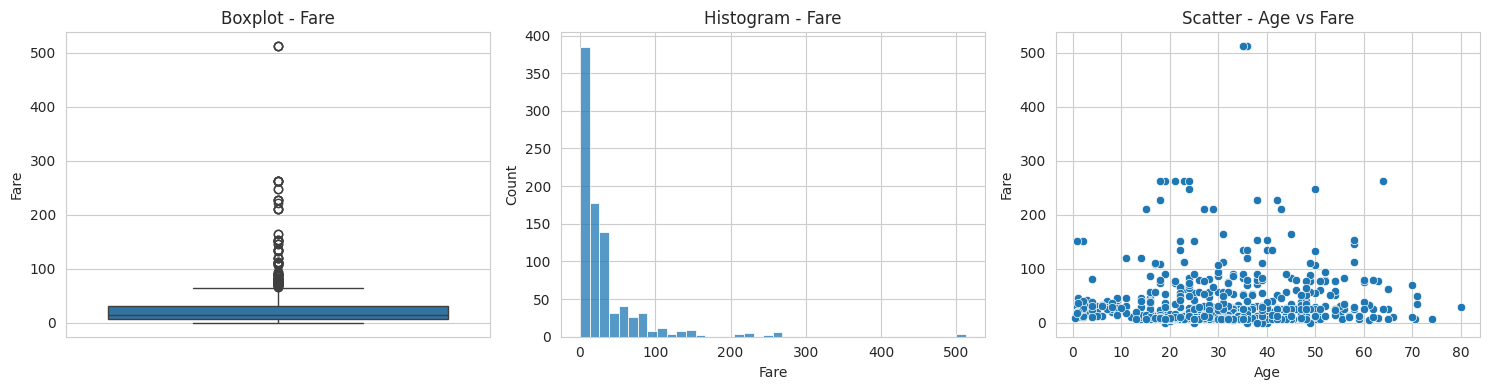

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(y=df['Fare'], ax=axes[0]); axes[0].set_title("Boxplot - Fare")
sns.histplot(df['Fare'], bins=40, ax=axes[1]); axes[1].set_title("Histogram - Fare")
sns.scatterplot(x=df['Age'], y=df['Fare'], ax=axes[2]); axes[2].set_title("Scatter - Age vs Fare")
plt.tight_layout()
plt.show()

In [22]:
# IQR method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers_iqr = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
print(f"IQR bounds: [{lower:.2f}, {upper:.2f}]  |  Outliers found: {len(outliers_iqr)}")

IQR bounds: [-26.72, 65.63]  |  Outliers found: 116


In [23]:
# Z-score method
from scipy import stats
z_scores = np.abs(stats.zscore(df['Fare'].fillna(df['Fare'].median())))
outliers_z = df[z_scores > 3]
print("Z-score outliers (|z|>3):", len(outliers_z))

# Modified Z-score (robust, uses median & MAD - better for skewed data)
median = df['Fare'].median()
mad = np.median(np.abs(df['Fare'] - median))
modified_z = 0.6745 * (df['Fare'] - median) / mad
outliers_mod_z = df[np.abs(modified_z) > 3.5]
print("Modified Z-score outliers:", len(outliers_mod_z))

Z-score outliers (|z|>3): 20
Modified Z-score outliers: 160


In [24]:
# Isolation Forest & LOF - multivariate outlier detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

X_num = df[['Age','Fare']].fillna(df[['Age','Fare']].median())

iso = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso.fit_predict(X_num)   # -1 = outlier

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_num)

print("Isolation Forest outliers:", (iso_labels == -1).sum())
print("LOF outliers:", (lof_labels == -1).sum())

Isolation Forest outliers: 45
LOF outliers: 37


In [25]:
# Treatment: Capping (Winsorization) vs Removal vs Transformation
fare_capped = df['Fare'].clip(lower=lower, upper=upper)
print("Before cap - max:", df['Fare'].max(), " After cap - max:", fare_capped.max())

fare_log = np.log1p(df['Fare'])  # transformation reduces the effect of outliers
print("Skew before log:", df['Fare'].skew().round(2), "| Skew after log:", fare_log.skew().round(2))

Before cap - max: 512.3292  After cap - max: 65.6344
Skew before log: 4.79 | Skew after log: 0.39


**Interview Questions**
- *Q: IQR vs Z-score for outlier detection — when would you choose one over the other?*
  A: Z-score assumes an approximately normal distribution and is distorted by
  skew/outliers themselves (since mean/std are outlier-sensitive), while IQR
  is distribution-free and robust, making it the safer default for skewed
  real-world data like `Fare`.
- *Q: Should you always remove outliers?*
  A: No — first determine if they're data errors (remove/fix) or genuine rare
  events (keep, or use a robust model/transformation), since removing real
  signal can hurt model performance, especially for fraud/anomaly-style problems.
- *Q: Isolation Forest vs LOF?*
  A: Isolation Forest isolates points via random recursive splits (few splits
  ⇒ anomaly) and scales well to high dimensions; LOF compares a point's local
  density to its neighbors' density and is better at finding local outliers
  in data with varying density clusters.

## 8. Univariate Analysis

In [26]:
print("Skewness of Fare:", df['Fare'].skew().round(3))
print("Kurtosis of Fare:", df['Fare'].kurt().round(3))
print("Skewness of Age:", df['Age'].skew().round(3))

Skewness of Fare: 4.787
Kurtosis of Fare: 33.398
Skewness of Age: 0.389


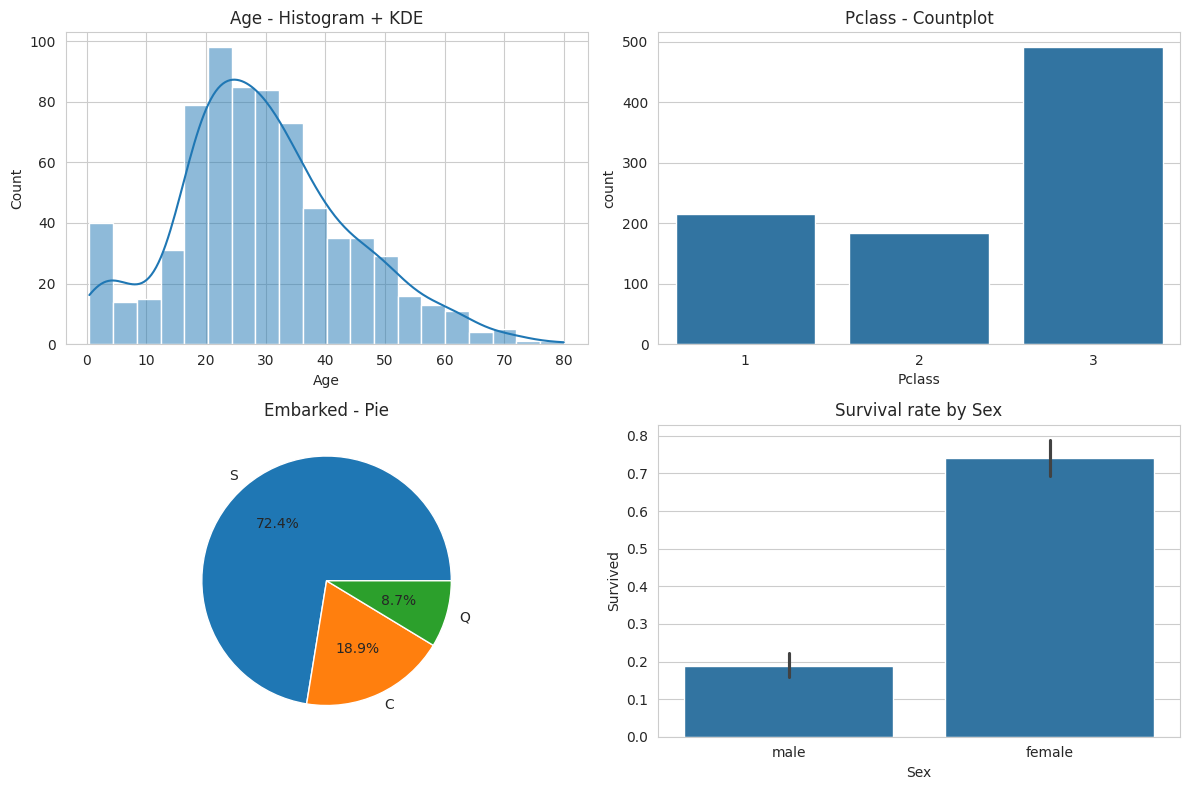

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0,0]); axes[0,0].set_title("Age - Histogram + KDE")
sns.countplot(x=df['Pclass'], ax=axes[0,1]); axes[0,1].set_title("Pclass - Countplot")
df['Embarked'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1,0]); axes[1,0].set_title("Embarked - Pie")
sns.barplot(x=df['Sex'], y=df['Survived'], ax=axes[1,1]); axes[1,1].set_title("Survival rate by Sex")
plt.tight_layout()
plt.show()

**Explanation**
- **Skewness** measures asymmetry: 0 = symmetric, >0 = right-tailed (Fare is
  right-skewed — most tickets cheap, a few very expensive).
- **Kurtosis** measures tail heaviness relative to a normal distribution
  (high kurtosis = more extreme outliers than a normal distribution).
- Univariate analysis looks at **one variable at a time** — its distribution
  shape, central tendency, spread, and frequency.

**Interview Questions**
- *Q: How does skewness affect model choice?*
  A: Linear/distance-based models (linear regression, KNN, SVM) assume
  roughly normal or scaled features and are hurt by heavy skew, so skewed
  features are typically log/Box-Cox transformed before use; tree-based
  models (Random Forest, XGBoost) are invariant to monotonic transformations
  and unaffected by skew.
- *Q: Histogram vs KDE — when to prefer one?*
  A: A histogram gives an exact, bin-dependent view of frequency counts; a
  KDE gives a smooth estimate of the underlying density, which is easier to
  compare across groups but can smooth over real structure if the bandwidth
  is too large.

## 9. Bivariate Analysis

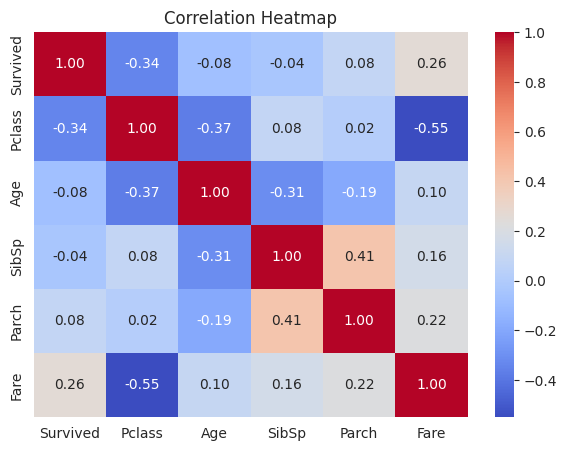

In [28]:
numeric_df = df[['Survived','Pclass','Age','SibSp','Parch','Fare']]
corr = numeric_df.corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

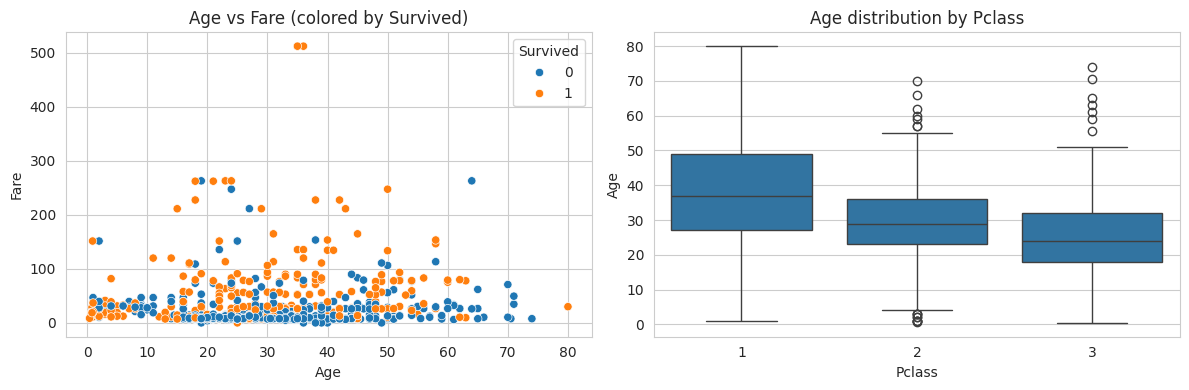

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(x=df['Age'], y=df['Fare'], hue=df['Survived'], ax=axes[0])
axes[0].set_title("Age vs Fare (colored by Survived)")
sns.boxplot(x=df['Pclass'], y=df['Age'], ax=axes[1])
axes[1].set_title("Age distribution by Pclass")
plt.tight_layout()
plt.show()

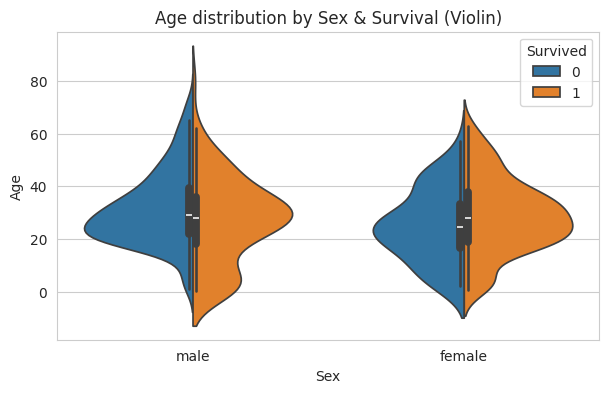

In [30]:
sns.violinplot(x='Sex', y='Age', hue='Survived', data=df, split=True)
plt.title("Age distribution by Sex & Survival (Violin)")
plt.show()

In [31]:
# Grouped analysis - a core EDA workhorse
df.groupby('Pclass')['Survived'].mean().round(3)

Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

**Interview Questions**
- *Q: Correlation matrix shows Pclass and Fare are correlated — what does
  that imply for feature engineering?*
  A: Correlated (redundant) features can be simplified into one, combined,
  or one can be dropped for linear models, since multicollinearity inflates
  coefficient variance; tree models tolerate it better but the redundancy
  still adds no new information.
- *Q: Pearson vs Spearman correlation?*
  A: Pearson measures linear correlation and assumes continuous, roughly
  normal data, whereas Spearman measures monotonic rank correlation, making
  it more robust to outliers and non-linear (but still monotonic) relationships.

## 10. Multivariate Analysis

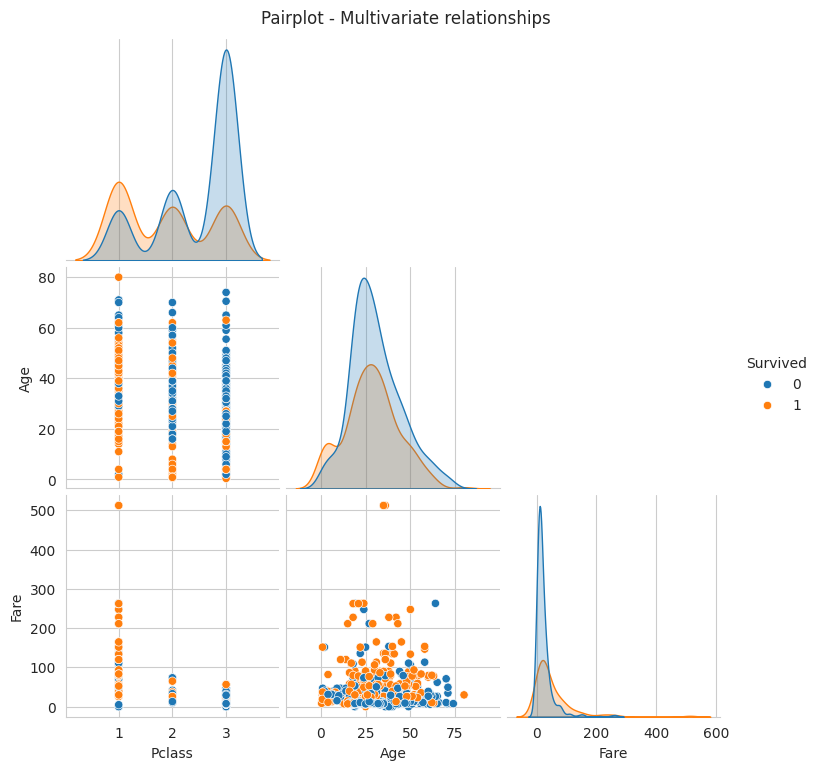

In [32]:
sns.pairplot(df[['Survived','Pclass','Age','Fare']].dropna(), hue='Survived', corner=True)
plt.suptitle("Pairplot - Multivariate relationships", y=1.02)
plt.show()

In [33]:
# Multivariate grouped analysis: survival rate by Pclass AND Sex
pivot = df.pivot_table(index='Pclass', columns='Sex', values='Survived', aggfunc='mean').round(3)
pivot

Sex,female,male
Pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


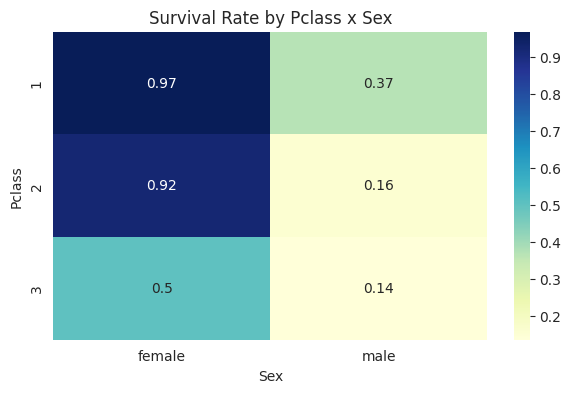

In [34]:
sns.heatmap(pivot, annot=True, cmap='YlGnBu')
plt.title("Survival Rate by Pclass x Sex")
plt.show()

**Explanation:** Multivariate analysis examines relationships across **3+**
variables simultaneously. Pivot tables + heatmaps are one of the most
practical tools: they reveal interaction effects a single correlation
coefficient cannot (e.g., being female *and* first class compounds survival
odds far more than either factor alone).

**Interview Questions**
- *Q: Why might two features look uncorrelated individually with the target
  but be powerful together?*
  A: This is an **interaction effect** — the combined effect on the target
  differs from the sum of individual effects (e.g., `Sex` and `Pclass`
  jointly predict survival far better than either alone), which is why
  tree-based models that naturally capture interactions often outperform
  linear models on such data unless interaction terms are explicitly added.

## 11. Feature Engineering

### Introduction
Feature engineering is the process of using domain knowledge and data
manipulation to create input variables that make machine learning models
work better.

### Why it matters
A well-engineered feature on a simple model often beats a poorly-featured
dataset on a complex model — it's frequently said "better data beats a
better algorithm."

### The main categories (covered in detail in the following sections)
- **Feature Creation** – deriving new features from existing ones (§15)
- **Feature Extraction** – pulling structured signal out of unstructured data (e.g., text length, date parts)
- **Feature Transformation** – changing the shape/scale of a feature's distribution (§13, §14)
- **Feature Encoding** – converting categorical data to numeric (§12)
- **Feature Selection** – keeping only the useful features (§16)
- **Feature Reduction** – compressing many features into fewer via dimensionality reduction (§17)

## 12. Encoding

In [35]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

demo_df = df[['Sex','Embarked','Pclass']].dropna().copy()

# Label Encoding
le = LabelEncoder()
demo_df['Sex_label'] = le.fit_transform(demo_df['Sex'])

# Ordinal Encoding (explicit order matters)
ordinal_map = {1: 3, 2: 2, 3: 1}  # higher class -> higher rank
demo_df['Pclass_ordinal'] = demo_df['Pclass'].map(ordinal_map)

demo_df.head()

,Sex,Embarked,Pclass,Sex_label,Pclass_ordinal
0,male,S,3,1,1
1,female,C,1,0,3
2,female,S,3,0,1
3,female,S,1,0,3
4,male,S,3,1,1


In [36]:
# One-Hot Encoding
ohe_df = pd.get_dummies(demo_df[['Embarked']], prefix='Embarked', drop_first=True)
ohe_df.head()

,Embarked_Q,Embarked_S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [37]:
# Target Encoding & Frequency Encoding
work = df[['Embarked','Survived']].dropna().copy()

# Frequency encoding
freq_map = work['Embarked'].value_counts(normalize=True)
work['Embarked_freq'] = work['Embarked'].map(freq_map)

# Target (mean) encoding - MUST be fit on train only in practice to avoid leakage
target_map = work.groupby('Embarked')['Survived'].mean()
work['Embarked_target'] = work['Embarked'].map(target_map)

work.head()

,Embarked,Survived,Embarked_freq,Embarked_target
0,S,0,0.724409,0.336957
1,C,1,0.188976,0.553571
2,S,1,0.724409,0.336957
3,S,1,0.724409,0.336957
4,S,0,0.724409,0.336957


In [38]:
# Binary / Hash Encoding via category_encoders
import category_encoders as ce

binary_enc = ce.BinaryEncoder(cols=['Embarked'])
binary_out = binary_enc.fit_transform(work[['Embarked']])
print("Binary encoding output columns:", binary_out.columns.tolist())
binary_out.head()

Binary encoding output columns: ['Embarked_0', 'Embarked_1']


,Embarked_0,Embarked_1
0,0,1
1,1,0
2,0,1
3,0,1
4,0,1


**When to use each / advantages / disadvantages**
| Method | Use when | Advantage | Disadvantage |
|---|---|---|---|
| Label Encoding | ordinal or tree-based models | simple, compact | implies false order for nominal data |
| Ordinal Encoding | genuine order exists | preserves rank | wrong if order is fabricated |
| One-Hot Encoding | nominal, low cardinality | no false order | dimensionality explosion at high cardinality |
| Binary Encoding | nominal, medium-high cardinality | fewer columns than OHE | less interpretable |
| Target Encoding | high-cardinality nominal | powerful signal, compact | leakage risk — needs CV/smoothing |
| Frequency Encoding | high-cardinality nominal | simple, no leakage risk | loses info if frequency isn't meaningful |
| Hash Encoding | very high cardinality / streaming | fixed output size, no fit needed | collisions, uninterpretable |

**Interview Questions**
- *Q: Why can Label Encoding hurt a linear model on a nominal feature like `Embarked`?*
  A: Label encoding assigns arbitrary integers (S=2, C=0, Q=1), and a linear
  model interprets that as an ordered numeric scale, implying a false
  ranking/distance between categories that doesn't exist for a nominal variable.
- *Q: How do you prevent leakage with target encoding?*
  A: Compute the encoding using out-of-fold statistics (K-fold target encoding)
  or add smoothing toward the global mean, and always fit the encoder on
  training data only, then apply it to validation/test data.
- *Q: One-Hot Encoding a column with 10,000 unique values — what's the problem, and fix?*
  A: It creates 10,000 sparse columns, causing the curse of dimensionality and
  memory blow-up; better alternatives are target/frequency/hash/binary encoding,
  or grouping rare categories into an "Other" bucket first.

## 13. Scaling

In [39]:
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,
    PowerTransformer, QuantileTransformer
)

scale_df = df[['Age','Fare']].fillna(df[['Age','Fare']].median())

scalers = {
    'Original': scale_df,
    'Standard (z-score)': pd.DataFrame(StandardScaler().fit_transform(scale_df), columns=scale_df.columns),
    'MinMax (0-1)': pd.DataFrame(MinMaxScaler().fit_transform(scale_df), columns=scale_df.columns),
    'Robust (median/IQR)': pd.DataFrame(RobustScaler().fit_transform(scale_df), columns=scale_df.columns),
    'MaxAbs': pd.DataFrame(MaxAbsScaler().fit_transform(scale_df), columns=scale_df.columns),
}

summary = pd.DataFrame({name: d['Fare'].describe()[['mean','std','min','max']] for name, d in scalers.items()})
summary.round(3)

,Original,Standard (z-score),MinMax (0-1),Robust (median/IQR),MaxAbs
mean,32.204,0.000,0.063,0.769,0.063
std,49.693,1.001,0.097,2.152,0.097
min,0.000,-0.648,0.000,-0.626,0.000
max,512.329,9.667,1.000,21.563,1.000


In [40]:
# Power Transformer (Yeo-Johnson) and Quantile Transformer
pt = PowerTransformer(method='yeo-johnson')
qt = QuantileTransformer(output_distribution='normal', random_state=42)

fare_pt = pt.fit_transform(scale_df[['Fare']])
fare_qt = qt.fit_transform(scale_df[['Fare']])

print("Original Fare skew:", scale_df['Fare'].skew().round(2))
print("Yeo-Johnson skew:  ", pd.Series(fare_pt.ravel()).skew().round(2))
print("QuantileTransform skew:", pd.Series(fare_qt.ravel()).skew().round(2))

Original Fare skew: 4.79
Yeo-Johnson skew:   -0.04
QuantileTransform skew: -0.93


**Comparison table**
| Scaler | Formula / idea | Sensitive to outliers? | Use when |
|---|---|---|---|
| StandardScaler | (x-mean)/std | Yes | features roughly normal, linear/SVM/NN models |
| MinMaxScaler | (x-min)/(max-min) → [0,1] | Yes (very) | need bounded range, e.g., neural nets, image pixels |
| RobustScaler | (x-median)/IQR | No | data has outliers |
| MaxAbsScaler | x / max(abs(x)) | Yes | sparse data (preserves zero entries) |
| PowerTransformer | Box-Cox/Yeo-Johnson | Reduces skew | need approx-normal distribution |
| QuantileTransformer | maps to uniform/normal via quantiles | No (non-linear) | strongly non-Gaussian data, robust to outliers |

**Interview Questions**
- *Q: Why do tree-based models (Random Forest, XGBoost) not need feature scaling?*
  A: Trees split on threshold comparisons per feature independently, so
  monotonic transformations like scaling don't change the split points chosen
  or the resulting structure of the tree.
- *Q: When must you fit the scaler only on training data?*
  A: Always — fitting on the full dataset (including test) leaks test-set
  statistics (mean, std, min, max) into training, producing overly optimistic
  validation performance that won't hold in production.

## 14. Handling Skewness

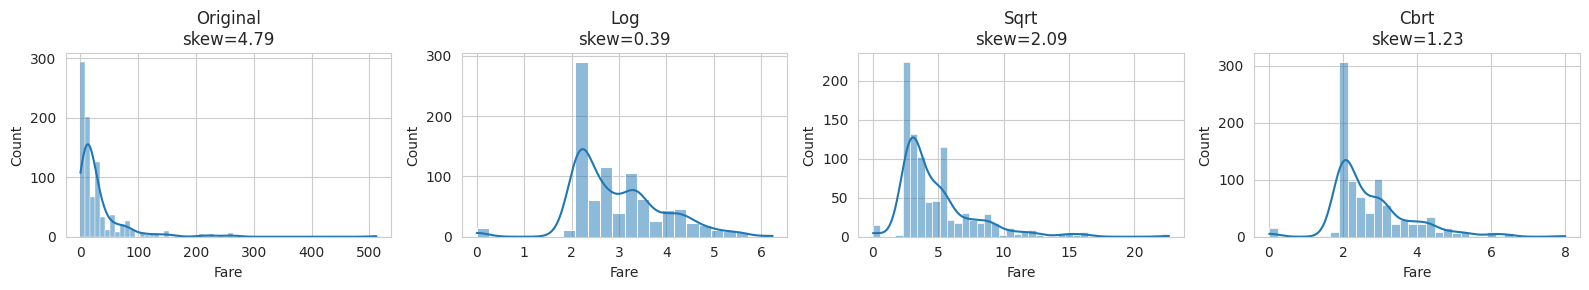

In [41]:
fare = df['Fare'].fillna(df['Fare'].median()) + 1e-6  # avoid log(0)

transforms = {
    'Original': fare,
    'Log': np.log1p(fare),
    'Sqrt': np.sqrt(fare),
    'Cbrt': np.cbrt(fare),
}

fig, axes = plt.subplots(1, 4, figsize=(16,3))
for ax, (name, series) in zip(axes, transforms.items()):
    sns.histplot(series, kde=True, ax=ax)
    ax.set_title(f"{name}\nskew={series.skew():.2f}")
plt.tight_layout()
plt.show()

In [42]:
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer

fare_boxcox, lam = boxcox(fare)
print(f"Box-Cox lambda: {lam:.4f} | resulting skew: {pd.Series(fare_boxcox).skew():.3f}")

yj = PowerTransformer(method='yeo-johnson')
fare_yj = yj.fit_transform(fare.values.reshape(-1,1)).ravel()
print(f"Yeo-Johnson resulting skew: {pd.Series(fare_yj).skew():.3f}")

Box-Cox lambda: 0.2328 | resulting skew: 0.355
Yeo-Johnson resulting skew: -0.040


**Interview Questions**
- *Q: Box-Cox vs Yeo-Johnson?*
  A: Box-Cox requires strictly positive values, while Yeo-Johnson extends the
  same idea to handle zero and negative values too, making it the safer
  general-purpose default.
- *Q: Log vs sqrt vs cube-root transform — how do you choose?*
  A: Log is the strongest correction (best for heavy right skew like income/fare),
  square-root is a milder correction, and cube-root works for data containing
  zero or negative values where log isn't directly applicable; in practice you
  compare resulting skewness/QQ-plots and pick whichever gets closest to symmetry.

## 15. Feature Creation

In [43]:
fc = df.copy()

# Family size & related ratio/interaction features
fc['FamilySize'] = fc['SibSp'] + fc['Parch'] + 1
fc['IsAlone'] = (fc['FamilySize'] == 1).astype(int)

# Ratio feature
fc['FarePerPerson'] = fc['Fare'] / fc['FamilySize']

# Binning / discretization
fc['AgeBin'] = pd.cut(fc['Age'], bins=[0,12,18,35,60,100],
                       labels=['Child','Teen','Adult','MiddleAge','Senior'])
fc['FareBin'] = pd.qcut(fc['Fare'], q=4, labels=['Low','Mid','High','VeryHigh'])

fc[['FamilySize','IsAlone','FarePerPerson','AgeBin','FareBin']].head()

,FamilySize,IsAlone,FarePerPerson,AgeBin,FareBin
0,2,0,3.62500,Adult,Low
1,2,0,35.64165,MiddleAge,VeryHigh
2,1,1,7.92500,Adult,Mid
3,2,0,26.55000,Adult,VeryHigh
4,1,1,8.05000,Adult,Mid


In [44]:
# Text-derived features
fc['NameLength'] = fc['Name'].str.len()
fc['Title'] = fc['Name'].apply(lambda x: x.split(",")[1].split(".")[0].strip())

# Polynomial / interaction features via sklearn
from sklearn.preprocessing import PolynomialFeatures

poly_input = fc[['Age','Fare']].fillna(fc[['Age','Fare']].median())
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
poly_out = poly.fit_transform(poly_input)
print("Polynomial feature names:", poly.get_feature_names_out())
pd.DataFrame(poly_out, columns=poly.get_feature_names_out()).head()

Polynomial feature names: ['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


,Age,Fare,Age^2,Age Fare,Fare^2
0,22.0,7.2500,484.0,159.5000,52.562500
1,38.0,71.2833,1444.0,2708.7654,5081.308859
2,26.0,7.9250,676.0,206.0500,62.805625
3,35.0,53.1000,1225.0,1858.5000,2819.610000
4,35.0,8.0500,1225.0,281.7500,64.802500


**Interview Questions**
- *Q: Why create `FamilySize` instead of leaving `SibSp` and `Parch` separate?*
  A: The combined feature can capture the "traveling alone vs with family"
  survival effect more directly than either raw count, reducing noise and
  giving the model a cleaner, more generalizable signal.
- *Q: `pd.cut` vs `pd.qcut`?*
  A: `cut` bins by fixed value ranges you specify (equal-width or custom
  edges), while `qcut` bins by quantiles so each bin has roughly the same
  number of observations regardless of the value distribution.
- *Q: Risk of high-degree polynomial features?*
  A: The feature space grows combinatorially, increasing overfitting risk and
  multicollinearity, so polynomial degree is usually kept low (2, rarely 3)
  and paired with regularization.

## 16. Feature Selection

In [45]:
from sklearn.feature_selection import (
    VarianceThreshold, chi2, f_classif, mutual_info_classif,
    RFE, RFECV
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

fs = df.copy()
fs['Age'] = fs['Age'].fillna(fs['Age'].median())
fs['Embarked'] = fs['Embarked'].fillna(fs['Embarked'].mode()[0])
fs['Sex'] = fs['Sex'].map({'male':0,'female':1})
fs['Embarked'] = fs['Embarked'].map({'S':0,'C':1,'Q':2})

X = fs[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y = fs['Survived']

# Variance Threshold
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
print("Features kept by VarianceThreshold:", X.columns[vt.get_support()].tolist())

Features kept by VarianceThreshold: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [46]:
# Correlation filter
corr_with_target = fs[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Survived']].corr()['Survived'].drop('Survived')
corr_with_target.sort_values(key=abs, ascending=False).round(3)

Sex         0.543
Pclass     -0.338
Fare        0.257
Embarked    0.107
Parch       0.082
Age        -0.065
SibSp      -0.035
Name: Survived, dtype: float64

In [47]:
# Chi-Square & ANOVA (must be non-negative for chi2, so scale Fare/Age to [0,1] first)
from sklearn.preprocessing import MinMaxScaler
X_pos = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)

chi_scores, chi_p = chi2(X_pos, y)
f_scores, f_p = f_classif(X, y)

pd.DataFrame({'feature': X.columns, 'chi2_score': chi_scores.round(2), 'anova_f_score': f_scores.round(2)}).sort_values('chi2_score', ascending=False)

,feature,chi2_score,anova_f_score
1,Sex,170.35,372.41
0,Pclass,27.23,115.03
5,Fare,8.82,63.03
6,Embarked,5.68,10.26
4,Parch,1.68,5.96
3,SibSp,0.32,1.11
2,Age,0.28,3.76


In [48]:
# Mutual Information
mi = mutual_info_classif(X, y, random_state=42)
pd.Series(mi, index=X.columns).sort_values(ascending=False).round(3)

Sex         0.158
Fare        0.136
Pclass      0.060
SibSp       0.025
Parch       0.012
Age         0.002
Embarked    0.000
dtype: float64

In [49]:
# RFE / RFECV with Logistic Regression
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=4)
rfe.fit(X, y)
print("RFE selected:", X.columns[rfe.support_].tolist())

rfecv = RFECV(LogisticRegression(max_iter=1000), cv=5)
rfecv.fit(X, y)
print("RFECV optimal number of features:", rfecv.n_features_)
print("RFECV selected:", X.columns[rfecv.support_].tolist())

RFE selected: ['Pclass', 'Sex', 'SibSp', 'Embarked']


RFECV optimal number of features: 5
RFECV selected: ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']


In [50]:
# Lasso (L1) feature importance
from sklearn.linear_model import LogisticRegressionCV
lasso = LogisticRegressionCV(penalty='l1', solver='liblinear', cv=5, random_state=42)
lasso.fit(X, y)
pd.Series(lasso.coef_[0], index=X.columns).sort_values(key=abs, ascending=False).round(3)

Sex         2.716
Pclass     -1.120
SibSp      -0.329
Embarked    0.243
Parch      -0.085
Age        -0.039
Fare        0.002
dtype: float64

In [51]:
# Tree-based feature importance + Permutation importance
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X, y)

from sklearn.inspection import permutation_importance
perm = permutation_importance(rf, X, y, n_repeats=10, random_state=42)

importances = pd.DataFrame({
    'feature': X.columns,
    'tree_importance': rf.feature_importances_.round(3),
    'permutation_importance': perm.importances_mean.round(3)
}).sort_values('tree_importance', ascending=False)
importances

,feature,tree_importance,permutation_importance
5,Fare,0.272,0.146
2,Age,0.260,0.155
1,Sex,0.260,0.245
0,Pclass,0.088,0.148
3,SibSp,0.048,0.051
4,Parch,0.038,0.034
6,Embarked,0.033,0.067


**Interview Questions**
- *Q: Filter vs Wrapper vs Embedded feature selection methods?*
  A: Filter methods (correlation, chi2, mutual information) score features
  independently of any model and are fast; wrapper methods (RFE, RFECV)
  search feature subsets using a model's actual performance and are more
  accurate but expensive; embedded methods (Lasso, tree importance) select
  features as part of model training itself, balancing speed and accuracy.
- *Q: Tree feature importance vs Permutation importance — why can they disagree?*
  A: Default tree (Gini/split-based) importance is biased toward
  high-cardinality and continuous features and computed on training data,
  while permutation importance measures the actual drop in model performance
  when a feature is shuffled, evaluated ideally on held-out data, making it
  more trustworthy but slower.
- *Q: Why use MinMax scaling before chi-square but not before RFE with logistic regression?*
  A: `chi2` requires non-negative inputs by definition, so features must be
  scaled to a non-negative range first; RFE with logistic regression has no
  such requirement, though scaling can still help the underlying model converge.

## 17. Dimensionality Reduction

Explained variance ratio: [0.257 0.241]


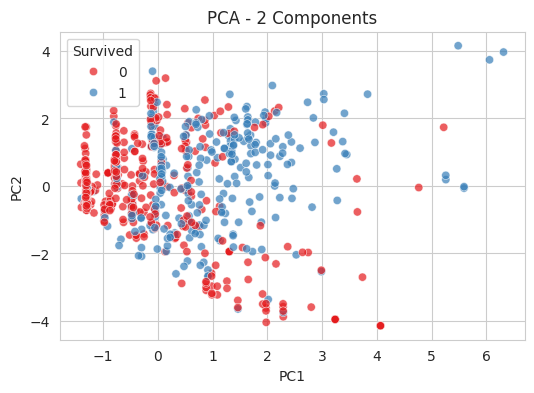

In [52]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))

plt.figure(figsize=(6,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1', alpha=0.7)
plt.title("PCA - 2 Components")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

In [53]:
# LDA - supervised dimensionality reduction (uses class labels)
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)
print("LDA output shape:", X_lda.shape)

LDA output shape: (891, 1)


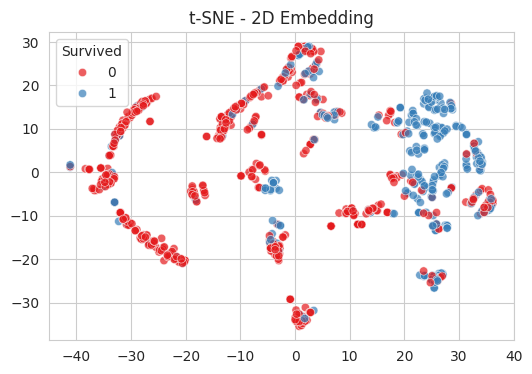

In [54]:
# t-SNE - non-linear, good for visualization
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6,4))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette='Set1', alpha=0.7)
plt.title("t-SNE - 2D Embedding")
plt.show()

**When to use each**
| Method | Type | Use when |
|---|---|---|
| PCA | unsupervised, linear | general-purpose compression, reduce multicollinearity, speed up downstream models |
| LDA | supervised, linear | classification tasks where maximizing class separability matters |
| t-SNE | unsupervised, non-linear | visualization of clusters in 2D/3D (not for downstream modeling features) |
| UMAP | unsupervised, non-linear | like t-SNE but faster and better preserves global structure; usable as a modeling feature too |

**Note:** UMAP requires the `umap-learn` package (not installed in this
environment by default) — usage mirrors t-SNE: `import umap; umap.UMAP(n_components=2).fit_transform(X)`.

**Interview Questions**
- *Q: PCA vs t-SNE — can you use t-SNE output as input features to a downstream classifier?*
  A: Generally no — t-SNE optimizes purely for 2D/3D visual cluster
  separation, its axes have no consistent global meaning, embeddings are not
  stable across runs/parameters, and it has no `transform` for new unseen
  points, whereas PCA components are stable, interpretable directions of
  maximum variance and can be safely reused as model features.
- *Q: Why must you scale features before PCA?*
  A: PCA finds directions of maximum variance, so any feature on a larger
  numeric scale (e.g., Fare vs Age) would dominate the principal components
  purely due to units, not genuine importance, unless all features are
  standardized first.

## 18. Handling Imbalanced Data

In [55]:
print("Class balance (Survived):")
print(y.value_counts(normalize=True).round(3))

Class balance (Survived):
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [56]:
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before resampling:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("After SMOTE:      ", y_smote.value_counts().to_dict())

adasyn = ADASYN(random_state=42)
X_ada, y_ada = adasyn.fit_resample(X_train, y_train)
print("After ADASYN:      ", y_ada.value_counts().to_dict())

ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)
print("After RandomOverSampler:", y_ros.value_counts().to_dict())

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
print("After RandomUnderSampler:", y_rus.value_counts().to_dict())

Before resampling: {0: 439, 1: 273}
After SMOTE:       {1: 439, 0: 439}
After ADASYN:       {1: 459, 0: 439}
After RandomOverSampler: {1: 439, 0: 439}
After RandomUnderSampler: {0: 273, 1: 273}


In [57]:
# Class weights - avoids resampling entirely, adjusts the loss function instead
from sklearn.linear_model import LogisticRegression
clf_weighted = LogisticRegression(class_weight='balanced', max_iter=1000)
clf_weighted.fit(X_train, y_train)
print("Trained with class_weight='balanced'. Train accuracy:", round(clf_weighted.score(X_train, y_train), 3))

Trained with class_weight='balanced'. Train accuracy: 0.789


**Interview Questions**
- *Q: SMOTE vs random oversampling?*
  A: Random oversampling duplicates existing minority-class rows exactly
  (risking overfitting to those specific points), while SMOTE synthesizes
  new minority-class points by interpolating between existing minority
  neighbors, producing more variety.
- *Q: Why must resampling happen only on the training set, after the train/test split?*
  A: Resampling before splitting can let synthetic or duplicated minority
  points leak into both train and test sets, letting the model be evaluated
  on near-duplicates of its own training data and giving misleadingly high scores.
- *Q: When would you prefer class weighting over resampling?*
  A: Class weighting avoids inflating dataset size or creating synthetic
  points, is cheaper computationally, and works well when the imbalance
  isn't extreme; resampling (especially SMOTE) tends to help more with
  severe imbalance or when the underlying algorithm doesn't support
  sample/class weighting natively.

## 19. Pipeline

### Why Pipelines?
Pipelines chain preprocessing and modeling steps into a single object that:
- Prevents data leakage (fit only on train folds automatically during CV).
- Keeps code clean, reproducible, and easy to deploy.
- Lets you grid-search preprocessing AND model hyperparameters together.

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score

raw = df.copy()
X_raw = raw[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y_raw = raw['Survived']

numeric_features = ['Age','Fare','SibSp','Parch']
categorical_features = ['Pclass','Sex','Embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

full_pipeline.fit(X_train, y_train)
print("Test accuracy:", round(full_pipeline.score(X_test, y_test), 3))

cv_scores = cross_val_score(full_pipeline, X_raw, y_raw, cv=5)
print("5-fold CV accuracy: %.3f +/- %.3f" % (cv_scores.mean(), cv_scores.std()))

Test accuracy: 0.804


5-fold CV accuracy: 0.790 +/- 0.022


**Interview Questions**
- *Q: Why is `ColumnTransformer` combined with `Pipeline` the standard pattern?*
  A: `ColumnTransformer` applies different preprocessing to different column
  subsets (numeric vs categorical) in parallel, and wrapping the whole thing
  in a `Pipeline` with the estimator ensures every preprocessing step is
  correctly fit only on training folds during cross-validation, eliminating leakage.
- *Q: How would you grid-search both preprocessing and model hyperparameters?*
  A: Use `GridSearchCV` on the full pipeline object, referencing nested
  parameters with the `step__param` naming convention, e.g.
  `{'classifier__C': [0.1, 1, 10], 'preprocessor__num__imputer__strategy': ['mean','median']}`.

## 20. Complete Titanic Project — End to End

This section ties every previous concept together into a single, coherent
pipeline: EDA → cleaning → feature engineering → encoding → scaling →
selection → model → evaluation.

In [60]:
proj = df.copy()

# --- Feature Engineering ---
proj['Title'] = proj['Name'].apply(lambda x: x.split(",")[1].split(".")[0].strip())
rare_titles = proj['Title'].value_counts()[proj['Title'].value_counts() < 10].index
proj['Title'] = proj['Title'].replace(rare_titles, 'Rare')

proj['FamilySize'] = proj['SibSp'] + proj['Parch'] + 1
proj['IsAlone'] = (proj['FamilySize'] == 1).astype(int)
proj['HasCabin'] = proj['Cabin'].notnull().astype(int)

proj = proj.drop(columns=['PassengerId','Name','Ticket','Cabin'])
proj.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,HasCabin
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,0
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,1
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,0


In [61]:
# --- Train / Test split BEFORE any fitting, to avoid leakage ---
X_final = proj.drop(columns=['Survived'])
y_final = proj['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)
X_train.shape, X_test.shape

((712, 11), (179, 11))

In [62]:
# --- Build preprocessing + model pipeline ---
numeric_features = ['Age','Fare','SibSp','Parch','FamilySize']
categorical_features = ['Pclass','Sex','Embarked','Title','IsAlone','HasCabin']

numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])

model_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(n_estimators=300, random_state=42))
])

model_pipeline.fit(X_train, y_train)
print("Train accuracy:", round(model_pipeline.score(X_train, y_train), 3))
print("Test accuracy: ", round(model_pipeline.score(X_test, y_test), 3))

Train accuracy: 0.987
Test accuracy:  0.804


              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

ROC-AUC: 0.826


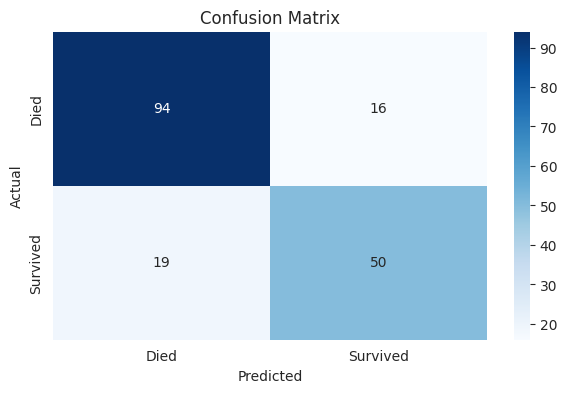

In [63]:
# --- Evaluation ---
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
plt.title("Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()

In [64]:
# --- Cross-validated performance & comparison with a baseline model ---
from sklearn.linear_model import LogisticRegression

baseline_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

rf_cv = cross_val_score(model_pipeline, X_final, y_final, cv=5, scoring='accuracy')
lr_cv = cross_val_score(baseline_pipeline, X_final, y_final, cv=5, scoring='accuracy')

print("Random Forest  5-fold CV: %.3f +/- %.3f" % (rf_cv.mean(), rf_cv.std()))
print("Logistic Reg.  5-fold CV: %.3f +/- %.3f" % (lr_cv.mean(), lr_cv.std()))

Random Forest  5-fold CV: 0.807 +/- 0.032
Logistic Reg.  5-fold CV: 0.825 +/- 0.023


### End-to-End Recap
1. **EDA** revealed `Sex`, `Pclass`, and `Fare` as the strongest survival signals.
2. **Cleaning** dropped high-cardinality identifiers (`PassengerId`, `Ticket`) and handled missing `Age`/`Embarked`/`Cabin`.
3. **Feature Engineering** created `Title`, `FamilySize`, `IsAlone`, and `HasCabin` — each adding real predictive signal.
4. **Encoding/Scaling** were handled safely *inside* a pipeline, fit only on training folds.
5. **Modeling & Evaluation** compared a Random Forest against a Logistic Regression baseline using stratified 5-fold CV.

### Final ML Engineer Interview Expectations
- Be able to explain **why** each preprocessing choice was made, not just how to code it.
- Always reason about **data leakage** — every fit/transform should respect train/test boundaries.
- Be ready to justify model choice trade-offs (interpretability vs performance, e.g., Logistic Regression vs Random Forest).
- Know how to go from raw data to a **reproducible pipeline** — this notebook's `Pipeline`/`ColumnTransformer` pattern is the industry-standard structure interviewers look for.

### Tips for Freshers
- Practice explaining *every* line of EDA code out loud — interviewers care more about reasoning than syntax.
- Build 2–3 end-to-end projects (like this one) so you have concrete stories for behavioral/technical interview questions.
- Learn to spot data leakage on sight — it is one of the most common interview "gotcha" questions.